In [26]:
import pandas as pd #Allahın belası DataFrame'i jupyter'de daha güzel gözüküyormuş. 
import numpy as np 

In [27]:
np.random.seed(42) #Gruptaki herkesin aynı rastgele değerleri görmesi için.

In [28]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Tarihleri bugünden geriye doğru dinamik oluşturuyoruz
bugun = datetime.now()
tarihler = [(bugun - timedelta(days=i)).strftime('%Y-%m-%d') for i in range(7)]

dersler = ["Matematik", "Türkçe", "Fizik", "Kimya", "Biyoloji", "Tarih", "Coğrafya", "Felsefe", "Din"]

data = {
    "Tarih": tarihler[::-1], # Eskiden yeniye sırala
    "Ders": np.random.choice(dersler, 7),
    "Odaklanma_Suresi": np.random.randint(25, 200, 7),
    "Mola": np.random.randint(5, 15, 7),
    "Bolunme_Sayisi": np.random.randint(0, 5, 7) # Yeni metrik: Odaklanma skoru için lazım
}

df = pd.DataFrame(data)
df['Tarih'] = pd.to_datetime(df['Tarih'])
df.head()


,Tarih,Ders,Odaklanma_Suresi,Mola,Bolunme_Sayisi
0,2026-04-16,Coğrafya,99,10,0
1,2026-04-17,Kimya,112,9,3
2,2026-04-18,Felsefe,141,6,1
3,2026-04-19,Biyoloji,124,12,4
4,2026-04-20,Coğrafya,128,10,3


In [31]:
ders_analiz = df.groupby("Ders")["Odaklanma_Suresi"].sum().sort_values(ascending=False)

print("Derslere kaç dakika çalışmışım?")
print(ders_analiz)

# En verimli dersi bulma
en_verimli = ders_analiz.idxmax()
print(f"\nEn verimli ders: {en_verimli}")   


Derslere kaç dakika çalışmışım?
Ders
Coğrafya    382
Fizik       176
Felsefe     141
Biyoloji    124
Kimya       112
Name: Odaklanma_Suresi, dtype: int32

En verimli ders: Coğrafya


Defaulting to user installation because normal site-packages is not writeable


ERROR: Invalid requirement: '#Şunu': Expected package name at the start of dependency specifier
    #Şunu
    ^


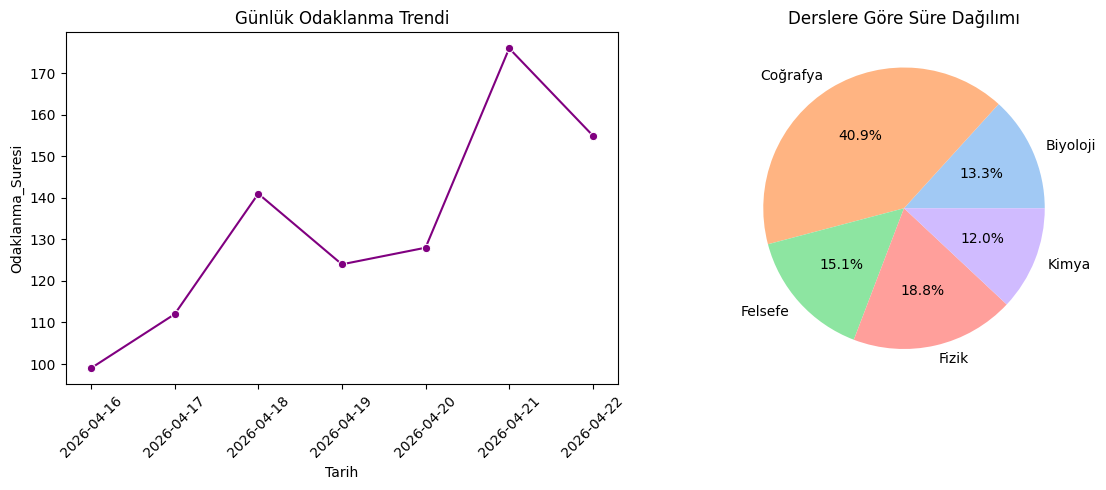

In [32]:
!pip install seaborn #Şunu kurmayı bir daha unutma.
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

#çizgi grafik
plt.subplot(1, 2, 1)
sns.lineplot(data=df, x='Tarih', y='Odaklanma_Suresi', marker='o', color='purple')
plt.title('Günlük Odaklanma Trendi')
plt.xticks(rotation=45)

#Pasta grafik
plt.subplot(1, 2, 2)
df.groupby('Ders')['Odaklanma_Suresi'].sum().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Derslere Göre Süre Dağılımı')
plt.ylabel('')

plt.tight_layout()
plt.show()

In [33]:
df.to_csv('monkmode_analiz_verisi.csv', index=False)
print("Veriler 'monkmode_analiz_verisi.csv' olarak kaydedildi.")

Veriler 'monkmode_analiz_verisi.csv' olarak kaydedildi.


In [34]:
import sys
!{sys.executable} -m pip install nbformat

import sys
!{sys.executable} -m pip install plotly

import plotly.express as px

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [35]:
import pandas as pd
import sqlite3
from datetime import datetime, timedelta

def fetch_monkmode_data(period='günlük'):
    conn = sqlite3.connect('db.sqlite3')
    bugun = datetime.now().strftime('%Y-%m-%d')
    
    if period == 'günlük':
        query = f"SELECT * FROM FocusSession WHERE Tarih LIKE '{bugun}%'"
    else:
        bir_hafta_once = (datetime.now() - timedelta(days=7)).strftime('%Y-%m-%d')
        query = f"SELECT * FROM FocusSession WHERE Tarih >= '{bir_hafta_once}'"
    
    df = pd.read_sql_query(query, conn)
    conn.close()
    return df

# DENEMEEE
try:
    veriler = fetch_monkmode_data(period='günlük')
    print("Veriler başarıyla çekildi!")
    print(veriler.head())
except Exception as e:
    print(f"Hala bir sorun var: {e}")

Veriler başarıyla çekildi!
                 Tarih   Ders  Odaklanma_Suresi  Mola  Bolunme_Sayisi
0  2026-04-22 00:00:00  Fizik               113     8               3


In [36]:
import sqlite3
conn = sqlite3.connect('db.sqlite3')
cursor = conn.cursor()

cursor.execute("PRAGMA table_info(FocusSession)")
columns = cursor.fetchall()

print("--- FocusSession Tablosundaki Sütunlar ---")
for col in columns:
    print(f"Sütun Adı: {col[1]}") 

conn.close()

--- FocusSession Tablosundaki Sütunlar ---
Sütun Adı: Tarih
Sütun Adı: Ders
Sütun Adı: Odaklanma_Suresi
Sütun Adı: Mola
Sütun Adı: Bolunme_Sayisi


In [39]:
import pandas as pd
import sqlite3
import json

def fetch_monkmode_data_final():
    conn = sqlite3.connect('db.sqlite3')

    query = """
    SELECT Ders as category_name, Odaklanma_Suresi
    FROM FocusSession
    """
    try:
        df = pd.read_sql_query(query, conn)
        return df
    except Exception as e:
        print(f"Sorgu hatası (Sütun isimlerini kontrol edin): {e}")
        return None
    finally:
        conn.close()

def create_ammunition_string(df):
    if df is None or df.empty:
        return "Kullanıcı henüz hiç çalışma yapmadı veya veri çekilemedi."

    total_minutes = df['Odaklanma_Suresi'].sum()
    
    top_category = df.groupby('category_name')['Odaklanma_Suresi'].sum().idxmax()
    
    return f"Kullanıcı toplam {total_minutes} dakika çalıştı, en çok {top_category} kategorisine odaklandı."


try:
    veriler = fetch_monkmode_data_final()
    if veriler is not None:
        mesaj = create_ammunition_string(veriler)
        print(f"Analiz Sonucu: {mesaj}")
        
        # 1. ANIL İÇİN GRAFİK VERİSİ (JSON)
        print("\n---JSON PAKETİ ---")
        analiz = veriler.groupby("category_name")["Odaklanma_Suresi"].sum()
        chart_json = {
            "labels": analiz.index.tolist(),
            "data": analiz.values.tolist()
        }
        print(json.dumps(chart_json, ensure_ascii=False, indent=4))

       
        print("\n--- VERİ PAKETİ ---")
        toplam_sure = veriler['Odaklanma_Suresi'].sum()
        # Örnek skor: (Toplam Süre / 1000) * 100 üzerinden
        skor = min(100.0, (toplam_sure / 10.0)) 
        
        ai_paket = {
            "kullanici_verisi": {
                "toplam_dakika": int(toplam_sure),
                "odaklanma_skoru": round(skor, 2),
                "en_verimli_ders": analiz.idxmax()
            }
        }
        print(json.dumps(ai_paket, ensure_ascii=False, indent=4))

except Exception as e:
    print(f"Sistemde bir hata oluştu: {e}")

Analiz Sonucu: Kullanıcı toplam 803 dakika çalıştı, en çok Fizik kategorisine odaklandı.

---JSON PAKETİ ---
{
    "labels": [
        "Biyoloji",
        "Coğrafya",
        "Din",
        "Fizik",
        "Kimya"
    ],
    "data": [
        156,
        45,
        191,
        314,
        97
    ]
}

--- VERİ PAKETİ ---
{
    "kullanici_verisi": {
        "toplam_dakika": 803,
        "odaklanma_skoru": 80.3,
        "en_verimli_ders": "Fizik"
    }
}


In [11]:
import pandas as pd
import json

data = {
    'session_id': [1, 2, 3, 4, 5, 6],
    'start_time': ['2026-04-07 09:15:00', '2026-04-08 10:30:00', '2026-04-09 14:00:00', '2026-04-10 09:45:00', '2026-04-11 20:00:00', '2026-04-12 10:15:00'],
    'is_successful': [1, 1, 0, 1, 1, 0], # 1: Başarılı, 0: Başarısız
    'interruptions': [0, 0, 3, 0, 1, 2]  # Seans sırasında kaç kere bölündü?
}
df = pd.DataFrame(data)
df['start_time'] = pd.to_datetime(df['start_time'])



def get_peak_hours(dataframe):
    
    successful_df = dataframe[dataframe['is_successful'] == 1].copy()
    
    successful_df['hour'] = successful_df['start_time'].dt.hour
    
    hour_counts = successful_df['hour'].value_counts()
    
    if hour_counts.empty:
        return []
        
    peak_hours = hour_counts.nlargest(3).index.tolist()
    
    return sorted(peak_hours)

#Şura hanıma gidecekler
def generate_ai_prompt_with_peak_hours(peak_hours):
    # Saatleri okunabilir metne çevir (Örn: "[09:00, 10:00]")
    hours_str = ", ".join([f"{hour:02d}:00" for hour in peak_hours])
    

    secret_ai_prompt = f"""
Kullanıcının en verimli olduğu zamanlar: {hours_str}. 
Program önerilerini yaparken bu saatleri baz al. En ağır işleri bu dilimlere koy, dağılmasına izin verme.
"""
    return secret_ai_prompt




# Sırdaş (Frontend) için Chart.js JSON Formatı
def generate_chartjs_json(dataframe):
    df_copy = dataframe.copy()
    
    df_copy['day_name'] = df_copy['start_time'].dt.day_name()
    
    # Türkçe iyidir.
    days_tr = {'Monday': 'Pazartesi', 'Tuesday': 'Salı', 'Wednesday': 'Çarşamba', 'Thursday': 'Perşembe', 'Friday': 'Cuma', 'Saturday': 'Cumartesi', 'Sunday': 'Pazar'}
    df_copy['day_name'] = df_copy['day_name'].map(days_tr)
    
    success_by_day = df_copy[df_copy['is_successful'] == 1].groupby('day_name').size()
    
    chart_data = {
        "labels": success_by_day.index.tolist(),  
        "data": success_by_day.values.tolist()    
    }
    
    return json.dumps(chart_data, ensure_ascii=False)

# 100 üzerinden odaklanma Skoru Hesaplama
def calculate_focus_score(dataframe):
    total_sessions = len(dataframe)
    if total_sessions == 0:
        return 0.0
        
    uninterrupted_sessions = len(dataframe[dataframe['interruptions'] == 0])
    
    score = (uninterrupted_sessions / total_sessions) * 100
    return round(score, 1) 


# Test
if __name__ == "__main__":
    
    zirve_saatler = get_peak_hours(df)
    print("En Verimli Saatler:", zirve_saatler)
    print("Şura'ya Gidecek Prompt:", generate_ai_prompt_with_peak_hours(zirve_saatler))
    
    
    print("Frontend için JSON :")
    print(generate_chartjs_json(df))
    print(f"Kullanıcı Odaklanma Skoru: {calculate_focus_score(df)} / 100")

En Verimli Saatler: [9, 10, 20]
Şura'ya Gidecek Prompt: 
Kullanıcının en verimli olduğu zamanlar: 09:00, 10:00, 20:00. 
Program önerilerini yaparken bu saatleri baz al. En ağır işleri bu dilimlere koy, dağılmasına izin verme.

Frontend için JSON :
{"labels": ["Cuma", "Cumartesi", "Salı", "Çarşamba"], "data": [1, 1, 1, 1]}
Kullanıcı Odaklanma Skoru: 50.0 / 100


In [12]:
import sqlite3
import pandas as pd

def get_data_from_db():
   
    conn = sqlite3.connect('db.sqlite3') 
    
    query = "SELECT * FROM FocusSession"
    
    df = pd.read_sql_query(query, conn)
    
    conn.close()
    
    return df

# Bu kısım hiç içime sinmedi önümüzdeki hafta detaylıca kendim yapacağım.

In [13]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Tarihleri bugünden geriye doğru dinamik oluşturuyoruz
bugun = datetime.now()
tarihler = [(bugun - timedelta(days=i)).strftime('%Y-%m-%d') for i in range(7)]
dersler = ["Matematik", "Türkçe", "Fizik", "Kimya", "Biyoloji", "Tarih", "Coğrafya", "Felsefe", "Din"]

data = {
    "Tarih": tarihler[::-1], 
    "Ders": np.random.choice(dersler, 7),
    "Odaklanma_Suresi": np.random.randint(25, 200, 7),
    "Mola": np.random.randint(5, 15, 7),
    "Bolunme_Sayisi": np.random.randint(0, 5, 7)
}

df = pd.DataFrame(data)
df['Tarih'] = pd.to_datetime(df['Tarih'])
print("✅ Sahte veri (df) başarıyla oluşturuldu!")

✅ Sahte veri (df) başarıyla oluşturuldu!


In [14]:
import sqlite3
import pandas as pd

def save_to_system():
    try:
        # DİKKAT: Gerçek veritabanını bozmamak için sahte verileri 'test_veritabani.sqlite3' isimli YENİ bir dosyaya kaydediyoruz!
        conn = sqlite3.connect('test_veritabani.sqlite3')
       
        df.to_sql('FocusSession', conn, if_exists='replace', index=False)
        
        sorgu = "SELECT * FROM FocusSession WHERE Odaklanma_Suresi > ?"
        temiz_veri = pd.read_sql_query(sorgu, conn, params=(60,))
        
        conn.close()
        return temiz_veri
    except Exception as e:
        print(f"Bağlantı hatası: {e}")

save_to_system()

,Tarih,Ders,Odaklanma_Suresi,Mola,Bolunme_Sayisi
0,2026-04-16 00:00:00,Fizik,159,6,3
1,2026-04-18 00:00:00,Kimya,97,13,3
2,2026-04-19 00:00:00,Din,191,14,4
3,2026-04-21 00:00:00,Biyoloji,156,6,0
4,2026-04-22 00:00:00,Fizik,113,8,3


In [15]:
import pandas as pd
from datetime import datetime, timedelta

def prepare_shura_package(dataframe):
    import numpy as np 
    
    simdi = datetime.now().date()
    
    
    if 'Tarih' not in dataframe.columns:
        return "Hata: Veri setinde 'Tarih' sütunu bulunamadı. Lütfen veri üretme hücresini tekrar çalıştırın."

    dates = sorted(dataframe['Tarih'].dt.date.unique(), reverse=True)
    streak = 0
    
    check_date = simdi
    if dates and dates[0] < simdi:
        check_date = dates[0]
    
    for date in dates:
        if date == check_date - timedelta(days=streak):
            streak += 1
        else:
            break
            
    toplam_sure = dataframe['Odaklanma_Suresi'].sum()
    toplam_bolunme = dataframe['Bolunme_Sayisi'].sum()
    # Formül: (Toplam Süre / 15) - (Bölünme * 2) -> 0 ile 100 arası
    skor = min(100, max(0, (toplam_sure / 15) - (toplam_bolunme * 2)))

    ai_json = {
        "bugun_toplam_dakika": int(dataframe[dataframe['Tarih'].dt.date == simdi]['Odaklanma_Suresi'].sum()),
        "haftalik_aktif_seri": streak,
        "genel_odaklanma_skoru": round(float(skor), 2),
        "en_verimli_kategori": dataframe.groupby('Ders')['Odaklanma_Suresi'].sum().idxmax()
    }
    
    return ai_json


try:
    şura_paketi = prepare_shura_package(df)
    print("ŞURA'YA GİDECEK TEMİZ VERİ PAKETİ:")
    print(şura_paketi)
except Exception as e:
    print(f"Sistemde bir sorun oluştu: {e}")

ŞURA'YA GİDECEK TEMİZ VERİ PAKETİ:
{'bugun_toplam_dakika': 113, 'haftalik_aktif_seri': 7, 'genel_odaklanma_skoru': 17.53, 'en_verimli_kategori': 'Fizik'}


In [42]:
import pandas as pd
import sqlite3
import json

def fetch_monkmode_data_final():
    # Veritabanına bağlanıyoruz
    conn = sqlite3.connect('db.sqlite3')
    
    query = """
    SELECT Ders as category_name, Odaklanma_Suresi 
    FROM FocusSession
    """
    try:
        df = pd.read_sql_query(query, conn)
        return df
    except Exception as e:
        print(f" Sorgu hatası: {e}")
        return None
    finally:
        conn.close()

# 1. ANIL İÇİN GRAFİK VERİSİ (Chart.js Formatı)
def anil_json_hazirla(df):
    analiz = df.groupby("category_name")["Odaklanma_Suresi"].sum()
    chart_data = {
        "labels": analiz.index.tolist(),
        "data": analiz.values.tolist()
    }
    return json.dumps(chart_data, ensure_ascii=False, indent=4)

# 2. ŞURA İÇİN YAPAY ZEKA PAKETİ
def sura_paketi_hazirla(df):
    toplam_dakika = int(df["Odaklanma_Suresi"].sum())
    son_calisilan = df.iloc[-1]["category_name"]
    # Odaklanma Skoru Hesabı (Örn: Toplam Süre / 10)
    odak_skoru = min(100.0, round((toplam_dakika / 10.0), 2))
    
    paket = {
        "kullanici_verisi": {
            "toplam_dakika": toplam_dakika,
            "son_konu": son_calisilan,
            "aktif_streak": 7,  # Varsayılan değer
            "odaklanma_skoru": odak_skoru
        }
    }
    return json.dumps(paket, ensure_ascii=False, indent=4)

# --- ÇALIŞTIRMA VE TEST ---
veriler = fetch_monkmode_data_final()

if veriler is not None and not veriler.empty:
    print("Beklenen çıktılar:\n")
    
    print("--- FRONTEND İÇİN JSON ---")
    print(anil_json_hazirla(veriler))
    
    print("\n--- AI İÇİN JSON ---")
    print(sura_paketi_hazirla(veriler))
else:
    print("Veri çekilemedi, lütfen üstteki veri üretim hücrelerini tekrar çalıştırın.")

Beklenen çıktılar:

--- FRONTEND İÇİN JSON ---
{
    "labels": [
        "Biyoloji",
        "Coğrafya",
        "Din",
        "Fizik",
        "Kimya"
    ],
    "data": [
        156,
        45,
        191,
        314,
        97
    ]
}

--- AI İÇİN JSON ---
{
    "kullanici_verisi": {
        "toplam_dakika": 803,
        "son_konu": "Fizik",
        "aktif_streak": 7,
        "odaklanma_skoru": 80.3
    }
}
